# **Импорт**

In [ ]:
import os
import time
import random
import numpy as np
import matplotlib.pyplot as plt
import gc

# Импорты PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# Вспомогательные утилиты
import gdown
from PIL import Image
import seaborn as sns
sns.set_style('darkgrid')

# Настройка устройства вычислений (GPU если доступен)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Используемое устройство: {device}")

# Скачивание датасета Строительной площадки
gdown.download('https://storage.yandexcloud.net/aiueducation/Content/base/l14/construction_256x192.zip', None, quiet=False)

# Распаковка
!unzip -qo construction_256x192.zip
print("Архив успешно распакован. Папки 'train' и 'val' готовы.")

Используемое устройство: cuda


Downloading...
From: https://storage.yandexcloud.net/aiueducation/Content/base/l14/construction_256x192.zip
To: /content/construction_256x192.zip
100%|██████████| 214M/214M [00:15<00:00, 13.9MB/s]


Архив успешно распакован. Папки 'train' и 'val' готовы.


# **Перекодирование масок**

In [ ]:
# Геометрия картинок
IMG_HEIGHT = 256
IMG_WIDTH = 192
TRAIN_DIRECTORY = 'train'
VAL_DIRECTORY = 'val'

# Исходные 16 цветов разметки
FLOOR = (100, 100, 100); CEILING = (0, 0, 100); WALL = (0, 100, 0); COLUMN = (100, 0, 0)
APERTURE = (0, 100, 100); DOOR = (100, 0, 100); WINDOW = (100, 100, 0); EXTERNAL = (200, 200, 200)
RAILINGS = (0, 200, 0); BATTERY = (200, 0, 0); PEOPLE = (0, 200, 200); LADDER = (0, 0, 200)
INVENTORY = (200, 0, 200); LAMP = (200, 200, 0); WIRE = (0, 100, 200); BEAM = (100, 0, 200)

# Группировка в 5 классов
class_0 = [WALL, COLUMN, BEAM]
class_1 = [FLOOR, CEILING]
class_2 = [APERTURE, DOOR, WINDOW]
class_3 = [RAILINGS, BATTERY, LADDER, INVENTORY, LAMP, WIRE]
class_4 = [EXTERNAL, PEOPLE]

def rgb_to_5_labels(images_list):
    masks_converted = []
    for img in images_list:
        sample = np.array(img)
        # Одноканальная маска индексов классов
        y = np.zeros((IMG_HEIGHT, IMG_WIDTH), dtype='uint8')

        for cl in class_0: y[np.all(sample == cl, axis=-1)] = 0
        for cl in class_1: y[np.all(sample == cl, axis=-1)] = 1
        for cl in class_2: y[np.all(sample == cl, axis=-1)] = 2
        for cl in class_3: y[np.all(sample == cl, axis=-1)] = 3
        for cl in class_4: y[np.all(sample == cl, axis=-1)] = 4
        masks_converted.append(y)
    return np.array(masks_converted, dtype='uint8')

def load_raw_images(base_dir, sub_dir):
    path = os.path.join(base_dir, sub_dir)
    files = sorted(os.listdir(path))
    images = []
    for f in files:
        img = Image.open(os.path.join(path, f)).resize((IMG_WIDTH, IMG_HEIGHT))
        images.append(np.array(img, dtype='uint8'))
    return np.array(images)

print("Загрузка оригинальных фотографий...")
x_train_raw = load_raw_images(TRAIN_DIRECTORY, 'original')
x_val_raw = load_raw_images(VAL_DIRECTORY, 'original')

print("Загрузка и конвертация масок в 5 классов...")
train_seg_raw = load_raw_images(TRAIN_DIRECTORY, 'segment')
val_seg_raw = load_raw_images(VAL_DIRECTORY, 'segment')

y_train_sparse = rgb_to_5_labels(train_seg_raw)
y_val_sparse = rgb_to_5_labels(val_seg_raw)

# Очищаем тяжелые временные массивы исходной разметки
del train_seg_raw, val_seg_raw
gc.collect()

print("\nДанные загружены в ОЗУ в экономичном формате:")
print("x_train_raw shape:", x_train_raw.shape, x_train_raw.dtype)
print("y_train_sparse shape:", y_train_sparse.shape, y_train_sparse.dtype)

Загрузка оригинальных фотографий...
Загрузка и конвертация масок в 5 классов...

Данные загружены в ОЗУ в экономичном формате:
x_train_raw shape: (1900, 256, 192, 3) uint8
y_train_sparse shape: (1900, 256, 192) uint8


# **Создание PyTorch Dataset и DataLoader**

In [ ]:
class ConstructionDataset(Dataset):
    def __init__(self, images, masks):
        self.images = images
        self.masks = masks

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        # Приводим изображение к float32 [0, 1] и меняем оси HWC -> CHW
        img = self.images[idx].astype(np.float32) / 255.0
        img = img.transpose(2, 0, 1)

        # Маска должна быть целочисленным тензором Long для CrossEntropyLoss
        mask = self.masks[idx].astype(np.int64)

        return torch.tensor(img, dtype=torch.float32), torch.tensor(mask, dtype=torch.long)

# Создаем загрузчики данных (размер пакета 8 по ТЗ задания Lite)
BATCH_SIZE = 8
train_dataset = ConstructionDataset(x_train_raw, y_train_sparse)
val_dataset = ConstructionDataset(x_val_raw, y_val_sparse)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

# **Определение гибкой параметризованной архитектуры SimpleUNet**

In [ ]:
class ParameterizedSimpleUNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=5, filters=16, kernel_size=3, activation_name='relu'):
        super().__init__()

        # Авторасчет паддинга для сохранения пространственного разрешения
        padding = kernel_size // 2

        # Выбор функции активации
        if activation_name == 'relu':
            self.act = nn.ReLU()
        elif activation_name == 'linear':
            self.act = nn.Identity()
        elif activation_name == 'selu':
            self.act = nn.SELU()
        elif activation_name == 'elu':
            self.act = nn.ELU()
        else:
            self.act = nn.ReLU()

        # Плечо сжатия (Энкодер)
        self.conv1 = nn.Conv2d(in_channels, filters, kernel_size=kernel_size, padding=padding)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Горлышко (Bottleneck)
        self.conv2 = nn.Conv2d(filters, filters * 2, kernel_size=kernel_size, padding=padding)

        # Плечо восстановления (Декодер)
        self.up3 = nn.ConvTranspose2d(filters * 2, filters, kernel_size=2, stride=2)
        # Входной канал равен filters * 2, так как мы склеиваем слои (skip connection)
        self.conv3 = nn.Conv2d(filters * 2, filters, kernel_size=kernel_size, padding=padding)

        # Финальный классификатор пикселей (Logits на выходе)
        self.final = nn.Conv2d(filters, out_channels, kernel_size=1)

    def forward(self, x):
        # Блок 1
        c1 = self.act(self.conv1(x))
        p1 = self.pool1(c1)

        # Блок 2 (Центр)
        c2 = self.act(self.conv2(p1))

        # Блок 3 (Апсэмплинг и Конкатенация)
        u3 = self.up3(c2)
        merged = torch.cat([c1, u3], dim=1) # Склейка по оси каналов
        c3 = self.act(self.conv3(merged))

        # Финальные логиты (в PyTorch Softmax встроен внутрь CrossEntropyLoss)
        logits = self.final(c3)
        return logits

# **Цикл обучения**

In [ ]:
# Конфигурации экспериментов по условию задания
experiments_config = [
    {"filters": 16, "kernel": 3, "activation": "relu"},       # 1
    {"filters": 32, "kernel": 3, "activation": "relu"},       # 2
    {"filters": 64, "kernel": 3, "activation": "relu"},       # 3
    {"filters": 32, "kernel": 5, "activation": "relu"},       # 4
    {"filters": 32, "kernel": 7, "activation": "relu"},       # 5
    {"filters": 32, "kernel": 3, "activation": "linear"},     # 6
    {"filters": 32, "kernel": 3, "activation": "selu"},       # 7
    {"filters": 32, "kernel": 3, "activation": "elu"},        # 8
    {"filters": 16, "kernel": 5, "activation": "elu"},        # 9
    {"filters": 64, "kernel": 5, "activation": "selu"}        # 10
]

history_logs = {}
final_accuracies = {}
EPOCHS_COUNT = 7

# Функция потерь
criterion = nn.CrossEntropyLoss()

for idx, config in enumerate(experiments_config, 1):
    exp_label = f"Эксп {idx} (F:{config['filters']}, K:{config['kernel']}, {config['activation']})"
    print(f"\n=== СТАРТ ЭКСПЕРИМЕНТА №{idx}/10: {exp_label} ===")

    # Инициализация модели, оптимизатора
    model = ParameterizedSimpleUNet(
        in_channels=3,
        out_channels=5,
        filters=config['filters'],
        kernel_size=config['kernel'],
        activation_name=config['activation']
    ).to(device)

    optimizer = optim.Adam(model.parameters(), lr=1e-4)
    val_acc_trend = []

    for epoch in range(1, EPOCHS_COUNT + 1):
        # --- ТРЕНИРОВКА ---
        model.train()
        train_loss = 0.0
        for imgs, msks in train_loader:
            imgs, msks = imgs.to(device), msks.to(device)

            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, msks)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        # --- ВАЛИДАЦИЯ ---
        model.eval()
        correct_pixels = 0
        total_pixels = 0
        with torch.no_grad():
            for imgs, msks in val_loader:
                imgs, msks = imgs.to(device), msks.to(device)
                outputs = model(imgs)
                # Получаем предсказанный класс для каждого пикселя
                preds = torch.argmax(outputs, dim=1)
                correct_pixels += (preds == msks).sum().item()
                total_pixels += msks.numel()

        epoch_val_acc = correct_pixels / total_pixels
        val_acc_trend.append(epoch_val_acc)
        print(f"Эпоха {epoch}/{EPOCHS_COUNT} | Train Loss: {train_loss/len(train_loader):.4f} | Val Accuracy: {epoch_val_acc:.4f}")

    # Сохраняем результаты
    history_logs[exp_label] = val_acc_trend
    final_accuracies[exp_label] = val_acc_trend[-1]

    # Жесткое освобождение ресурсов GPU и ОЗУ перед следующим циклом!
    del model, optimizer
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    gc.collect()
    time.sleep(0.5)

print("\n\n[УСПЕХ] Все 10 экспериментов на PyTorch выполнены стабильно!")


=== СТАРТ ЭКСПЕРИМЕНТА №1/10: Эксп 1 (F:16, K:3, relu) ===
Эпоха 1/7 | Train Loss: 1.2662 | Val Accuracy: 0.6321
Эпоха 2/7 | Train Loss: 1.1036 | Val Accuracy: 0.6321
Эпоха 3/7 | Train Loss: 1.0481 | Val Accuracy: 0.6321
Эпоха 4/7 | Train Loss: 1.0264 | Val Accuracy: 0.6326
Эпоха 5/7 | Train Loss: 1.0183 | Val Accuracy: 0.6325
Эпоха 6/7 | Train Loss: 1.0138 | Val Accuracy: 0.6335
Эпоха 7/7 | Train Loss: 1.0099 | Val Accuracy: 0.6338

=== СТАРТ ЭКСПЕРИМЕНТА №2/10: Эксп 2 (F:32, K:3, relu) ===
Эпоха 1/7 | Train Loss: 1.2100 | Val Accuracy: 0.6321
Эпоха 2/7 | Train Loss: 1.0551 | Val Accuracy: 0.6321
Эпоха 3/7 | Train Loss: 1.0324 | Val Accuracy: 0.6321
Эпоха 4/7 | Train Loss: 1.0115 | Val Accuracy: 0.6328
Эпоха 5/7 | Train Loss: 0.9882 | Val Accuracy: 0.6359
Эпоха 6/7 | Train Loss: 0.9680 | Val Accuracy: 0.6042
Эпоха 7/7 | Train Loss: 0.9598 | Val Accuracy: 0.6136

=== СТАРТ ЭКСПЕРИМЕНТА №3/10: Эксп 3 (F:64, K:3, relu) ===
Эпоха 1/7 | Train Loss: 1.1263 | Val Accuracy: 0.6321
Эпоха 2/7 

# **Визуализация**

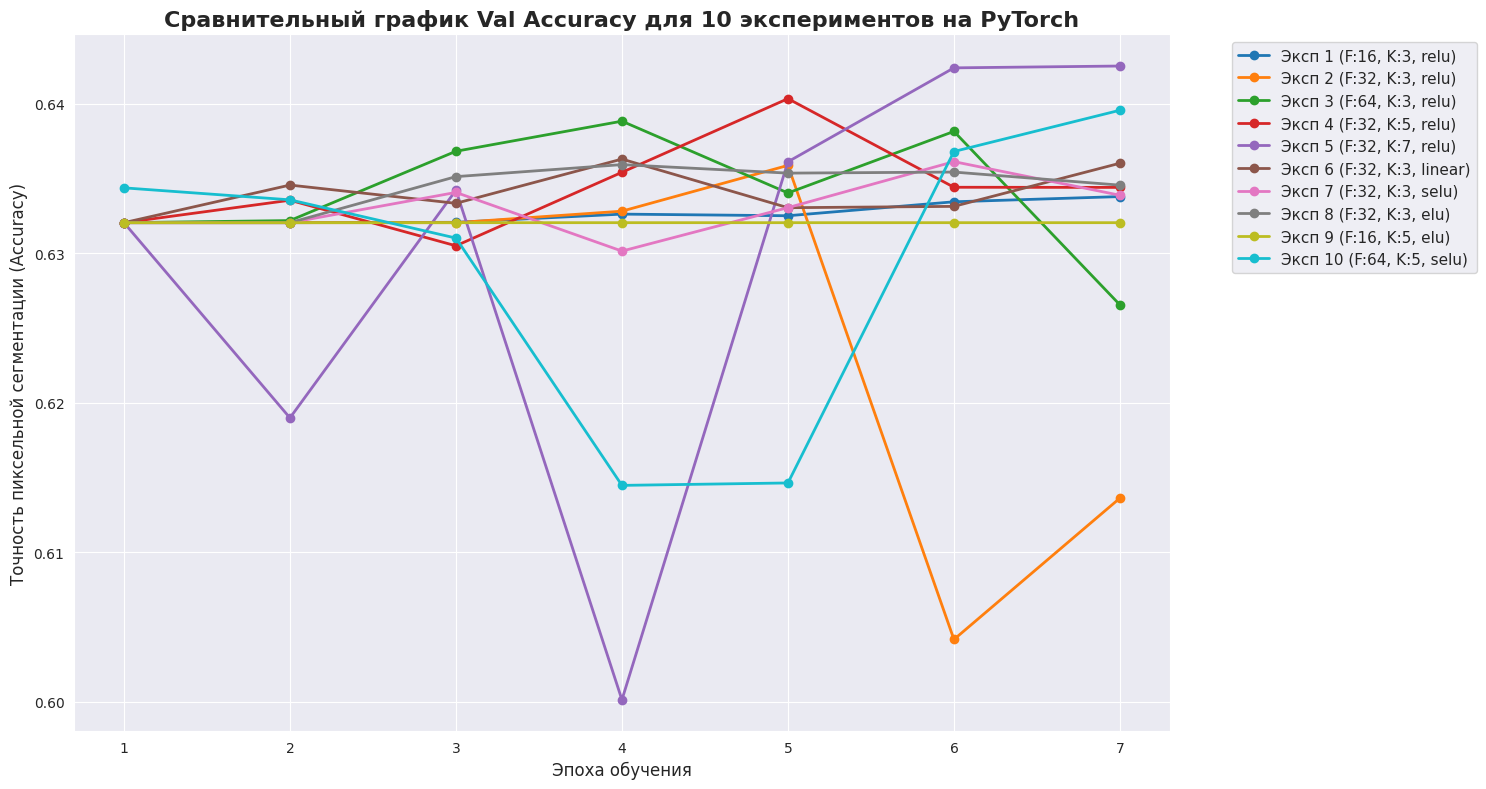


Рейтинг конфигураций по финальной точности (PyTorch):
Место 1: Эксп 5 (F:32, K:7, relu) -> Точность: 64.25%
Место 2: Эксп 10 (F:64, K:5, selu) -> Точность: 63.96%
Место 3: Эксп 6 (F:32, K:3, linear) -> Точность: 63.60%
Место 4: Эксп 8 (F:32, K:3, elu) -> Точность: 63.46%
Место 5: Эксп 4 (F:32, K:5, relu) -> Точность: 63.44%
Место 6: Эксп 7 (F:32, K:3, selu) -> Точность: 63.39%
Место 7: Эксп 1 (F:16, K:3, relu) -> Точность: 63.38%
Место 8: Эксп 9 (F:16, K:5, elu) -> Точность: 63.21%
Место 9: Эксп 3 (F:64, K:3, relu) -> Точность: 62.66%
Место 10: Эксп 2 (F:32, K:3, relu) -> Точность: 61.36%


In [ ]:
plt.figure(figsize=(15, 8))

# Отрисовываем тренд точности для каждого проведенного теста
for label, accuracy_trend in history_logs.items():
    plt.plot(range(1, EPOCHS_COUNT + 1), accuracy_trend, marker='o', label=label, linewidth=2)

plt.title('Сравнительный график Val Accuracy для 10 экспериментов на PyTorch', fontsize=16, fontweight='bold')
plt.xlabel('Эпоха обучения', fontsize=12)
plt.ylabel('Точность пиксельной сегментации (Accuracy)', fontsize=12)
plt.xticks(range(1, EPOCHS_COUNT + 1))
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=11)
plt.grid(True)
plt.tight_layout()
plt.show()

# Печать рейтинга эффективности
print("\nРейтинг конфигураций по финальной точности (PyTorch):")
sorted_rating = sorted(final_accuracies.items(), key=lambda item: item[1], reverse=True)
for rank, (name, acc) in enumerate(sorted_rating, 1):
    print(f"Место {rank}: {name} -> Точность: {acc*100:.2f}%")